In [1]:
import search
from PIL import Image
import numpy as np
import skimage
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
class PathPlanning(search.Problem):

    def __init__(self, image_filename):
        img = Image.open("map.png")
        img.load()
        self.map = np.asarray(img)
        self.initial = (0, 0)
        self.goal = (self.map.shape[0]-1, self.map.shape[1]-1)
        self.visited = self.map.copy()
        self.n_gen = 0

    def actions(self, state):
        result = []
        (i, j) = state
        for di in range(-1, 2):
            for dj in range(-1, 2):
                if (di,dj)!=(0,0):
                    (ni, nj) = (i+di, j+dj)
                    if ni>=0 and ni<self.map.shape[0] and \
                       nj>=0 and nj<self.map.shape[1] and \
                       self.map[ni,nj]==0:
                        result.append((di, dj))
        return result

    def result(self, state, action):
        (i, j) = state
        (di, dj) = action
        (ni, nj) = (i+di, j+dj)
        self.visited[ni,nj] = 100
        self.n_gen += 1
        return (ni, nj)

    def goal_test(self, state):
        return state==self.goal

    def path_cost(self, c, state1, action, state2):
        return c + np.linalg.norm(np.array(state2) - np.array(state1))
    
    def mark_solution(self, solution):
        if solution is not None:
            self.visited[solution.state] = 200
            self.mark_solution(solution.parent)

Solution cost: 67.11269837220806
Depth of the solution: 58
Number of generated nodes: 5331


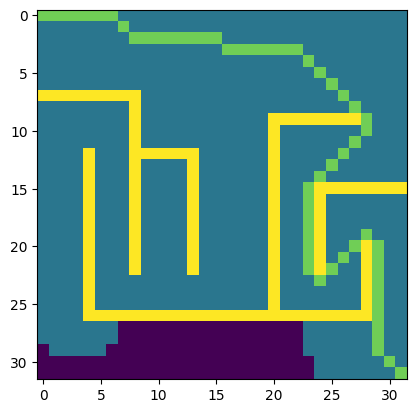

In [25]:
problem = PathPlanning("map.png")

#solution = search.breadth_first_graph_search(problem)
#solution = search.depth_first_graph_search(problem)
solution = search.uniform_cost_search(problem)

problem.mark_solution(solution)
print("Solution cost:", solution.path_cost)
print("Depth of the solution:", solution.depth)
print("Number of generated nodes:", problem.n_gen)

plt.figure()
plt.imshow(problem.visited)
plt.show()

In [26]:
class PathPlanningInformed(PathPlanning):
    def __init__(self, *args):
        super().__init__(*args)
        costs = np.ones_like(problem.map, dtype=np.int32)
        costs[problem.map>0] = -1
        mcp = skimage.graph.MCP_Geometric(costs)
        (self.cum_costs,_) = mcp.find_costs([problem.goal])

    def h_simple(self, node):
        return np.linalg.norm(np.array(node.state) - np.array(self.goal))

    def h_perfect(self, node):
        return self.cum_costs[node.state]        


Solution cost: 67.11269837220806
Depth of the solution: 58
Number of generated nodes: 1617


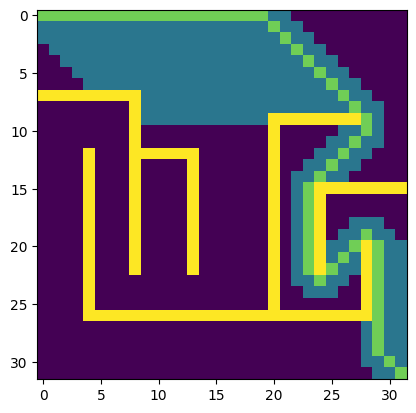

In [28]:
problem = PathPlanningInformed("map.png")

solution = search.astar_search(problem, problem.h_perfect)

problem.mark_solution(solution)
print("Solution cost:", solution.path_cost)
print("Depth of the solution:", solution.depth)
print("Number of generated nodes:", problem.n_gen)

plt.figure()
plt.imshow(problem.visited)
plt.show()